In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
# import UserUtilityFunctions as uf
# import UserStatisticalFunctions as usf
# import UserVisualization as uv
import UserMetricsFunctions as umf

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/5Clean_ML_Heart_CAT.pkl")
df_full = pd.read_pickle("../Data/5Clean_BeforeDummyEcode_CAT.pkl")

In [3]:
df.shape, df_full.shape

((15701, 218), (15701, 140))

### Split Dataset

In [4]:
from sklearn.model_selection import train_test_split

# split X & y
X = df.drop(columns = 'Survival')
y = df.Survival

# mapping values
y = y.map({'Dead': True, 'Living': False})

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### RandomForestClassifier

In [5]:
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# grid search Hyperparameters Random Forest Classfiier
parameters = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [8, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 7]
}


# Initialize Model with class weights
rfc_param = {'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
model = RandomForestClassifier(**rfc_param)

# CV with grid search for Hyper-Parameter tuning
rfc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score = 'accuracy')

# best model
model = rfc_fit.best_estimator_

CV accuracy: 0.766 +/- 0.011


In [6]:
print(model)

RandomForestClassifier(class_weight={False: 0.9487838042000302,
                                     True: 1.057061100824777},
                       max_depth=7, min_samples_leaf=15, min_samples_split=40,
                       n_estimators=500, random_state=1776)


#### Train`

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.72      0.77      6619
        True       0.73      0.83      0.78      5941

    accuracy                           0.77     12560
   macro avg       0.78      0.78      0.77     12560
weighted avg       0.78      0.77      0.77     12560



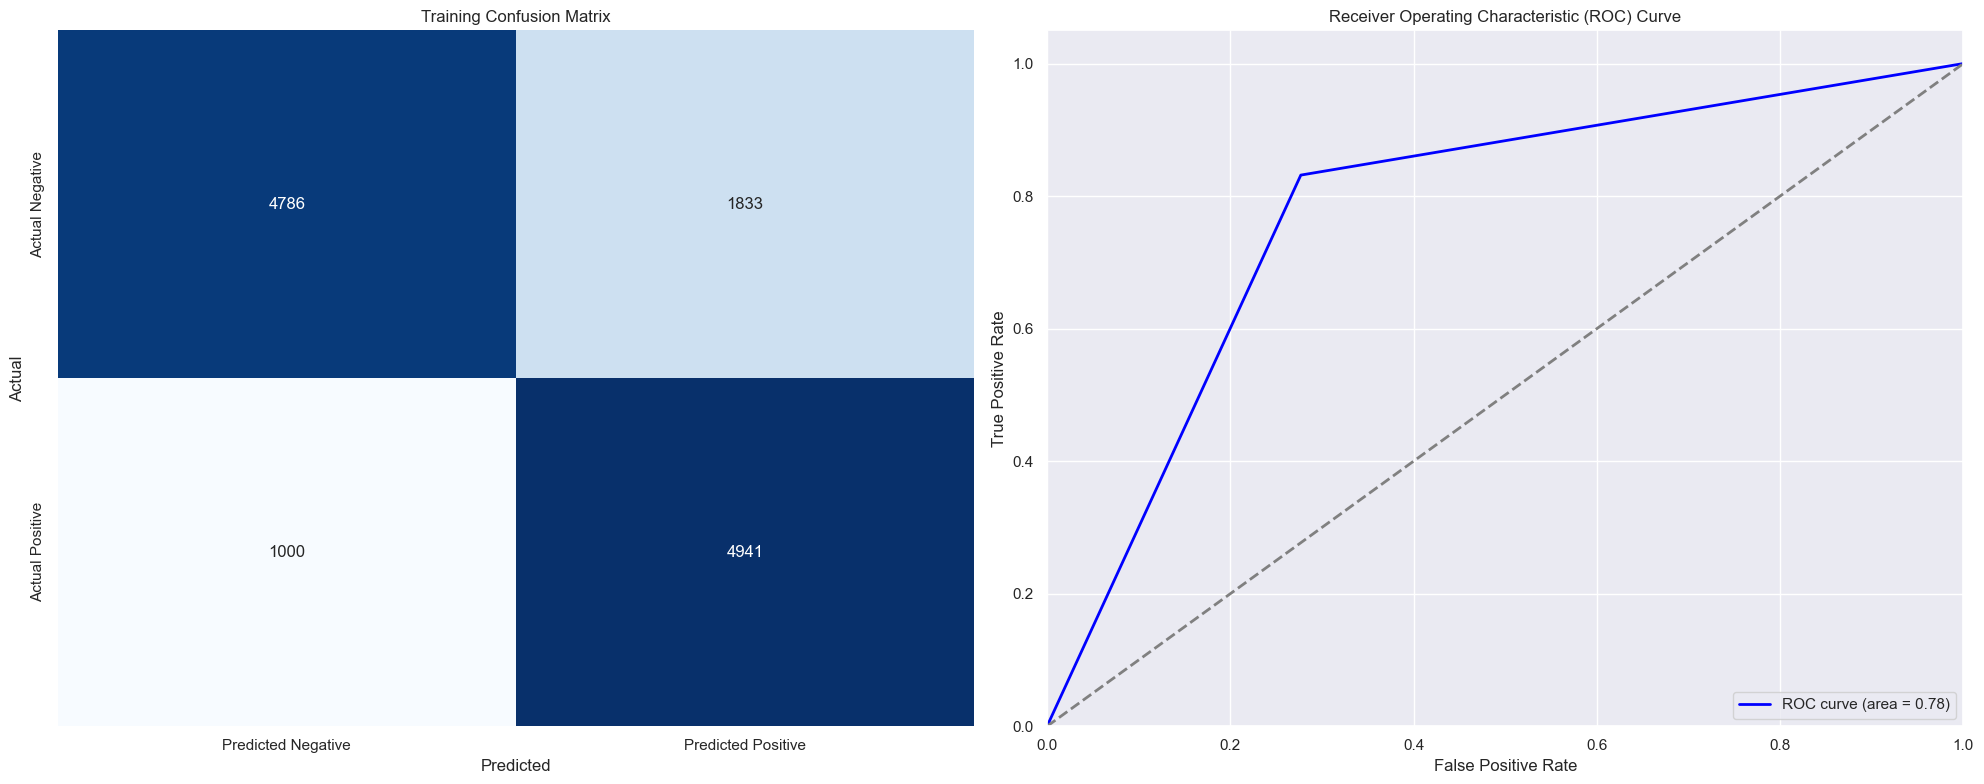

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.72307,0.777374


In [7]:
# initialize variables
Algorithm = 'RandomForestClassifier'
Desc = 'RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed'
Model = 'rfc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=None)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.72      0.77      1655
        True       0.73      0.82      0.77      1486

    accuracy                           0.77      3141
   macro avg       0.77      0.77      0.77      3141
weighted avg       0.77      0.77      0.77      3141



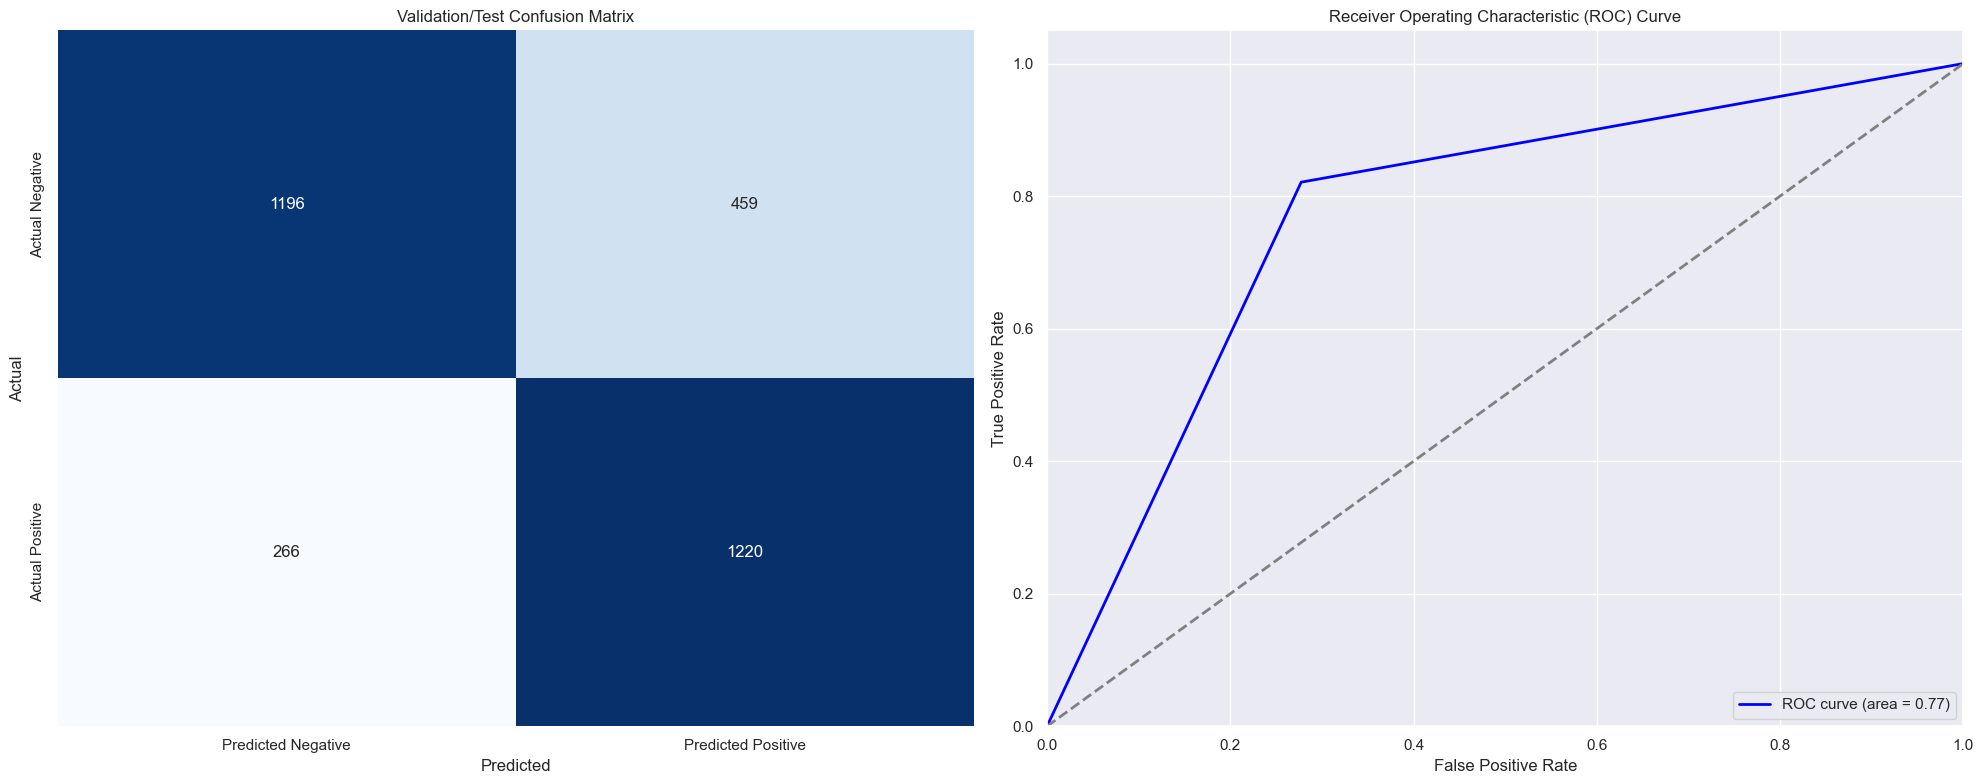

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827


In [8]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, df_classfication)
df_classfication

### LogisticRegression

In [9]:
# import library
from sklearn.linear_model import LogisticRegression

# define the hyperparameter grid to search
parameters = dict(
C = list(np.round(np.linspace(0.01, 5, 20),2))
)

# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate LogisticRegression Classifier
model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
lrc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = lrc_fit.best_estimator_

CV accuracy: 0.775 +/- 0.009


In [10]:
print(model)

LogisticRegression(C=0.27,
                   class_weight={False: 0.9487838042000302,
                                 True: 1.057061100824777},
                   max_iter=10000, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.71      0.77      6619
        True       0.73      0.87      0.79      5941

    accuracy                           0.78     12560
   macro avg       0.79      0.79      0.78     12560
weighted avg       0.79      0.78      0.78     12560



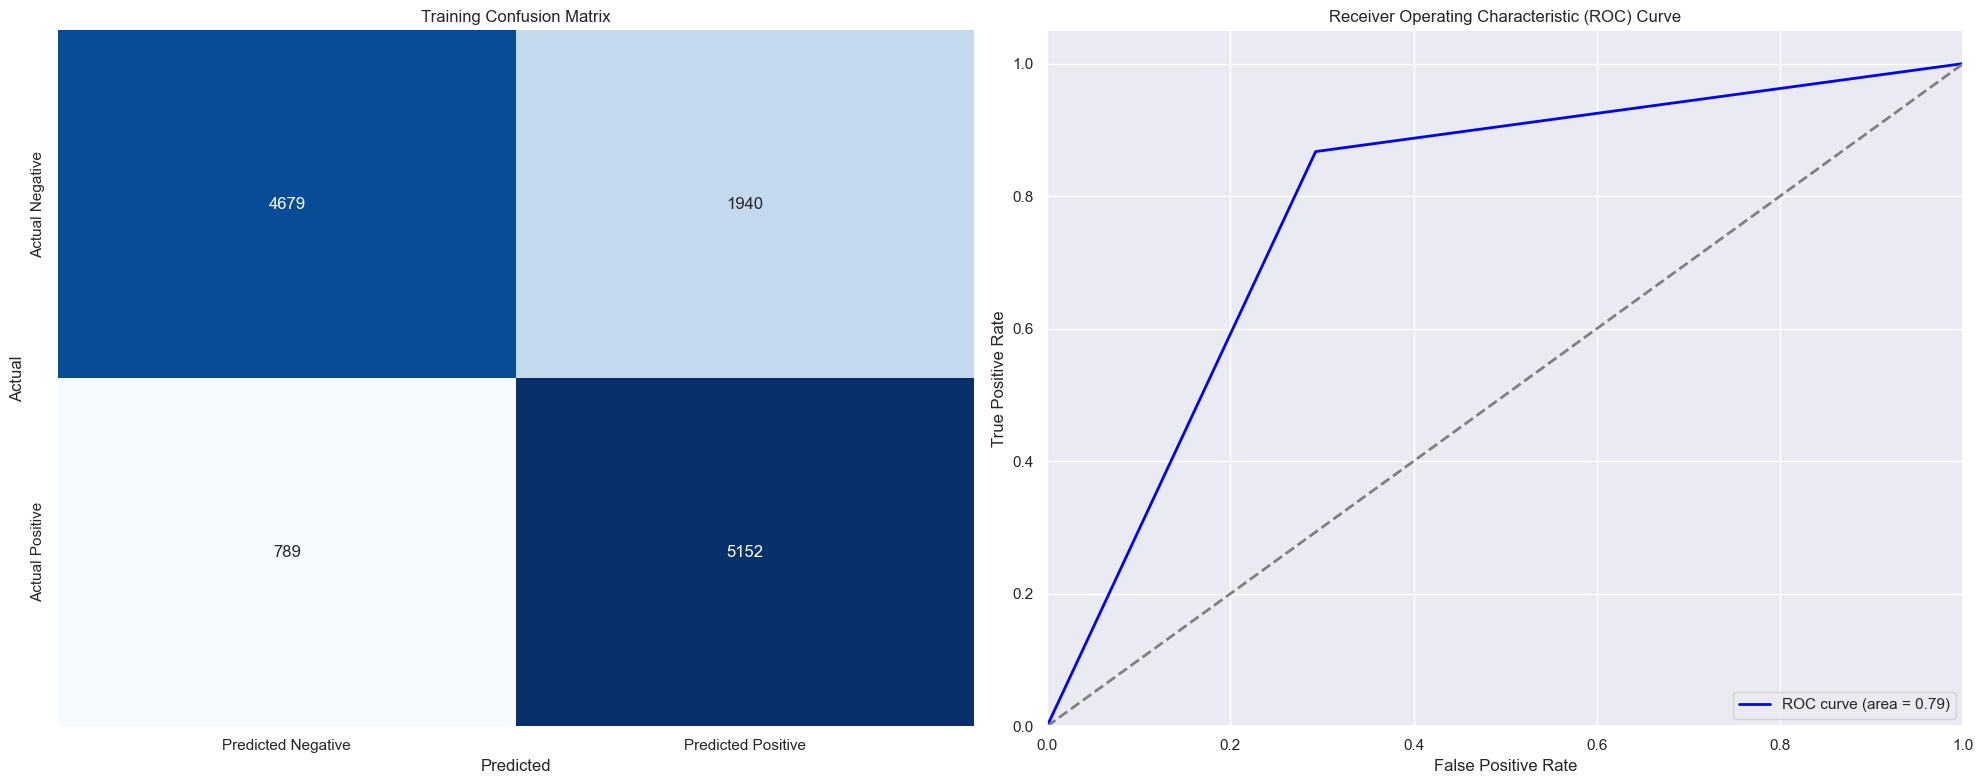

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049


In [11]:
# initialize variables
Algorithm = 'LogisticRegression'
Desc = 'LogisticRegression - Grid Search - Features where variance <= 0.01 removed'
Model = 'lrc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.70      0.77      1655
        True       0.72      0.87      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.79      0.78      0.78      3141



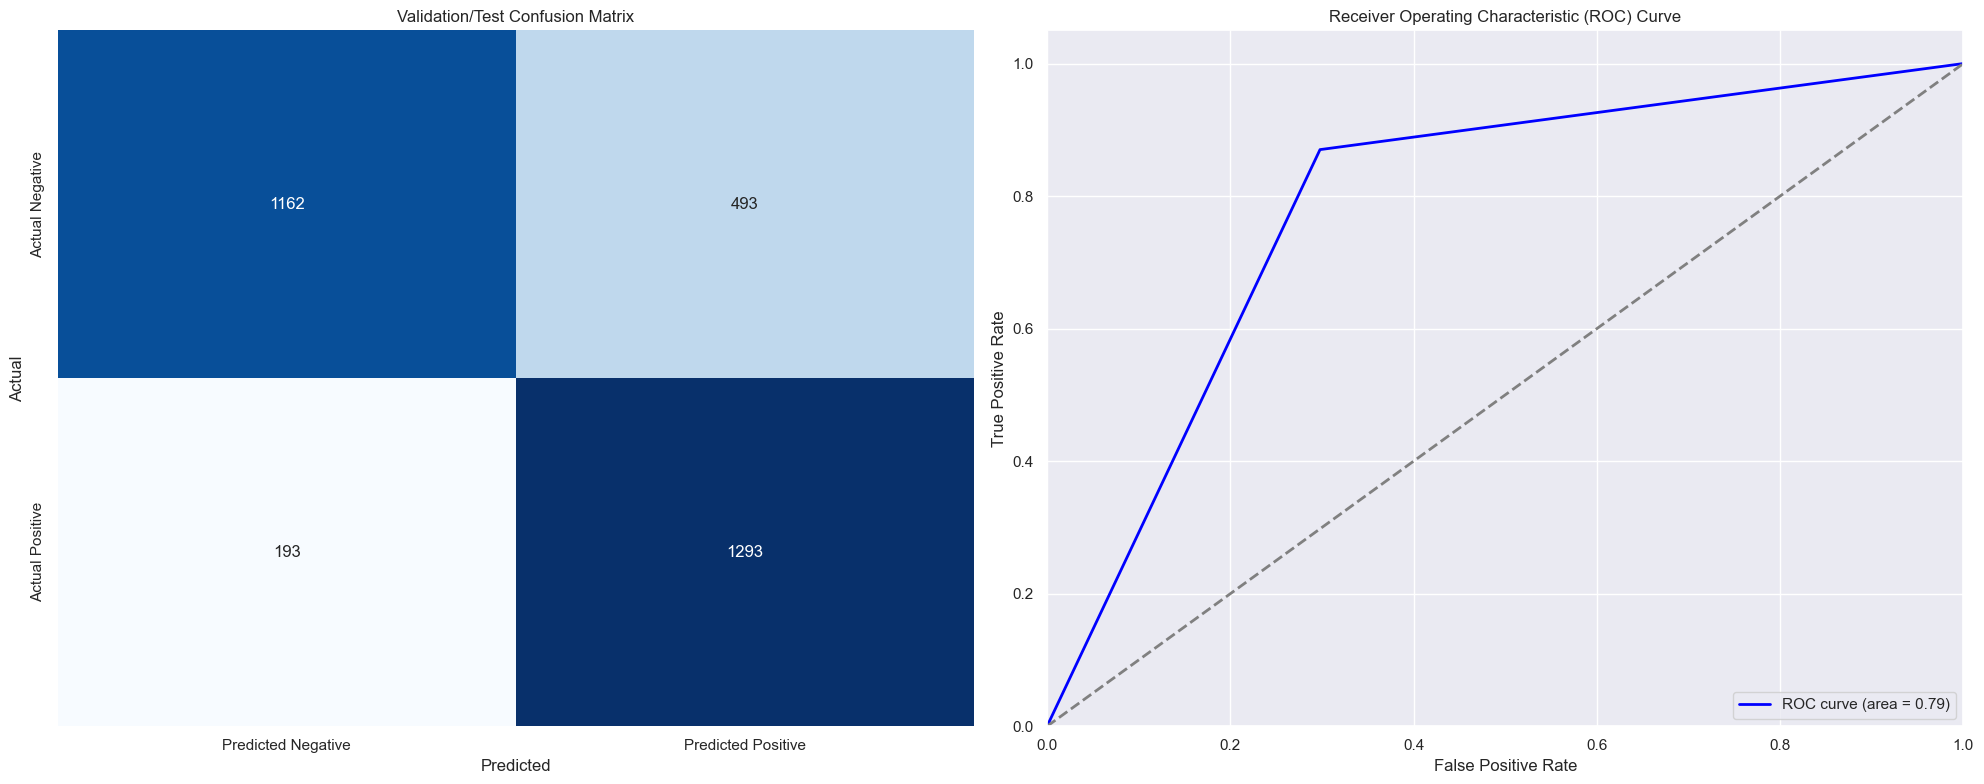

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118


In [12]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [13]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the hyperparameter grid to search
parameters = dict(
n_estimators = [50, 100, 200],
max_depth = [3, 5],
learning_rate = [0.01, 0.05, 0.1],
subsample = [0.4, 0.7],
gamma = [0.8, 1, 5]   # regularization term that controls the minimum loss reduction required to make a split at a node.
)

# Base Model
xgb_param = {'scale_pos_weight': scale_pos_weight, 'random_state': RANDOM_STATE}

# instantiate XGB Classifier
model = XGBClassifier(**xgb_param)

# CV with grid search for Hyper-Parameter tuning
xgb_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = xgb_fit.best_estimator_

CV accuracy: 0.780 +/- 0.011


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [14]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1776, ...)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.71      0.79      6619
        True       0.73      0.89      0.81      5941

    accuracy                           0.80     12560
   macro avg       0.81      0.80      0.80     12560
weighted avg       0.81      0.80      0.80     12560



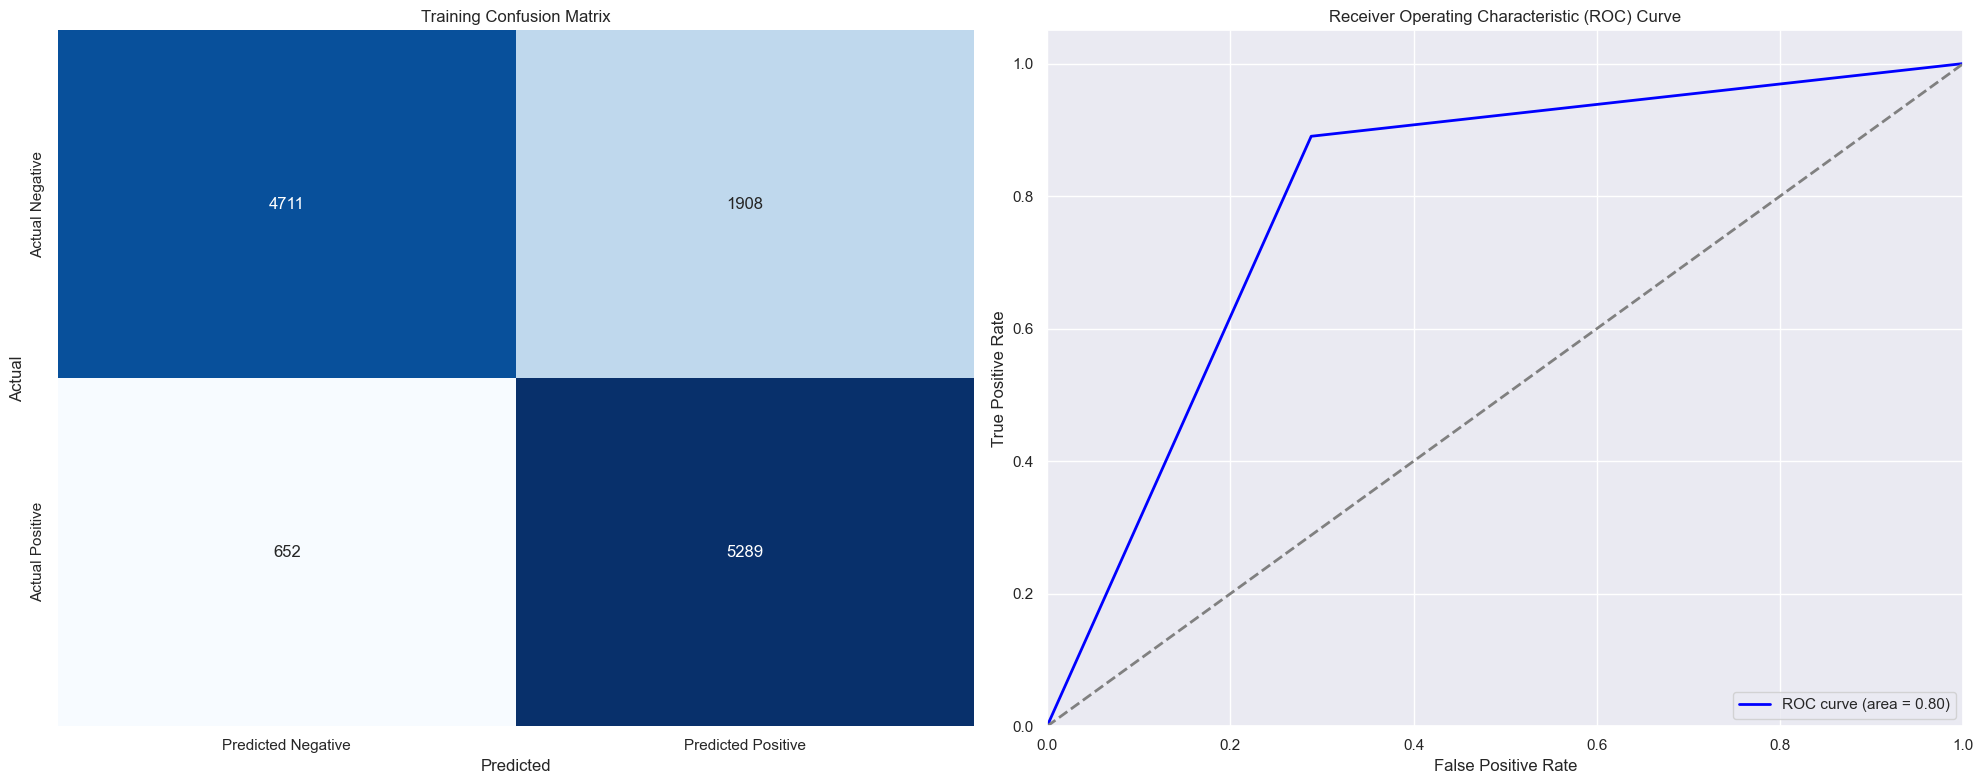

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997


In [15]:
# initialize variables
Algorithm = 'XGBClassifier'
Desc = 'XGBClassifier - Grid Search - Features where variance <= 0.01 removed'
Model = 'xgb_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.69      0.77      1655
        True       0.72      0.89      0.80      1486

    accuracy                           0.78      3141
   macro avg       0.80      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



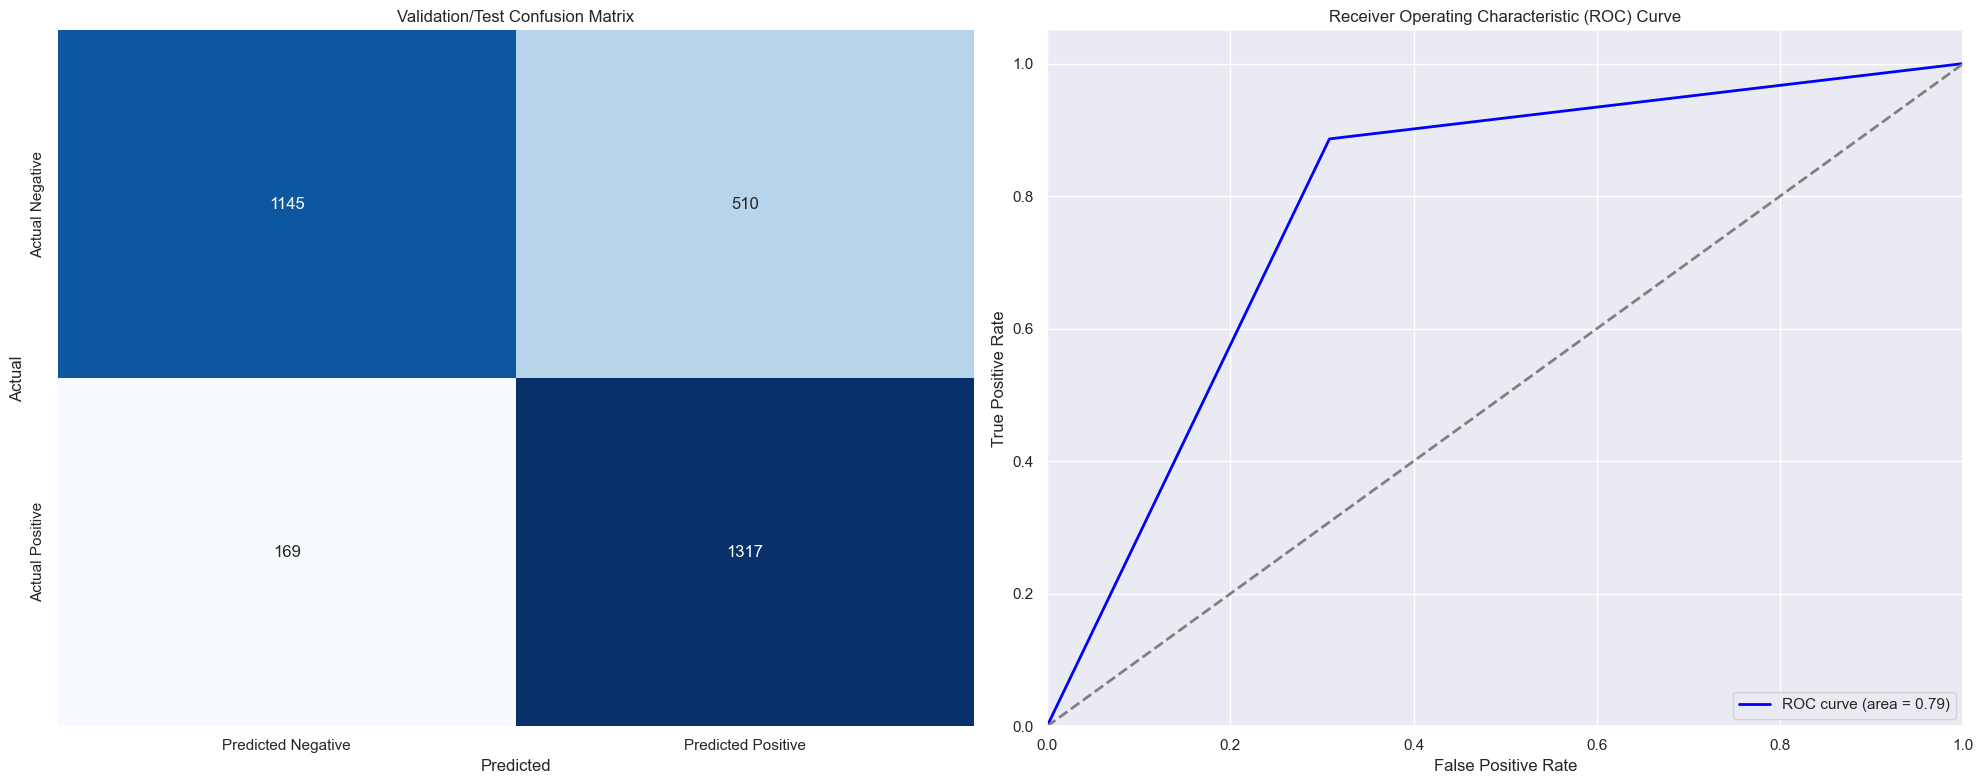

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783827,0.886272,0.795050,0.692677,0.720854,0.691843,0.789057


In [16]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [17]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'leaf_size': [10, 30, 50]
}

# create a KNN model
model = KNeighborsClassifier()

# CV with grid search for Hyper-Parameter tuning
knn_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = knn_fit.best_estimator_

CV accuracy: 0.677 +/- 0.008


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [18]:
print(model)

KNeighborsClassifier(leaf_size=10, metric='manhattan', n_neighbors=7)


#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.82      0.80      6619
        True       0.79      0.73      0.76      5941

    accuracy                           0.78     12560
   macro avg       0.78      0.78      0.78     12560
weighted avg       0.78      0.78      0.78     12560



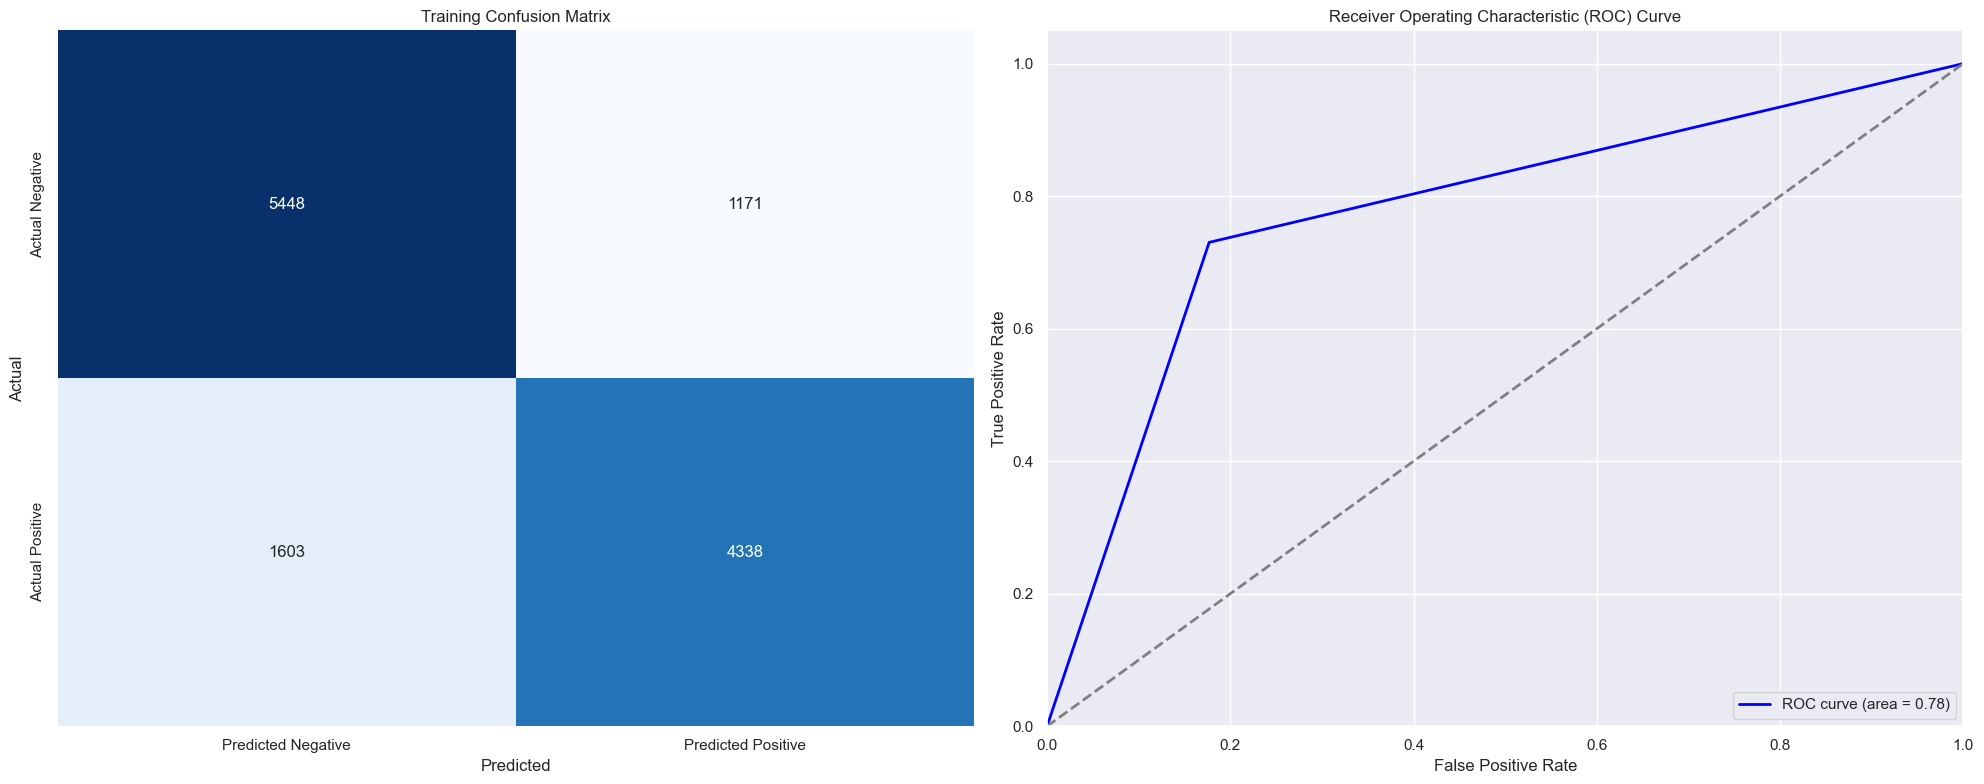

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783827,0.886272,0.795050,0.692677,0.720854,0.691843,0.789057
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.779140,0.730180,0.757729,0.702599,0.787439,0.823085,0.776633


In [19]:
# initialize variables
Algorithm = 'KNN'
Desc = 'KNN - Grid Search - All Features'
Model = 'knn_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.68      0.73      0.71      1655
        True       0.68      0.62      0.65      1486

    accuracy                           0.68      3141
   macro avg       0.68      0.68      0.68      3141
weighted avg       0.68      0.68      0.68      3141



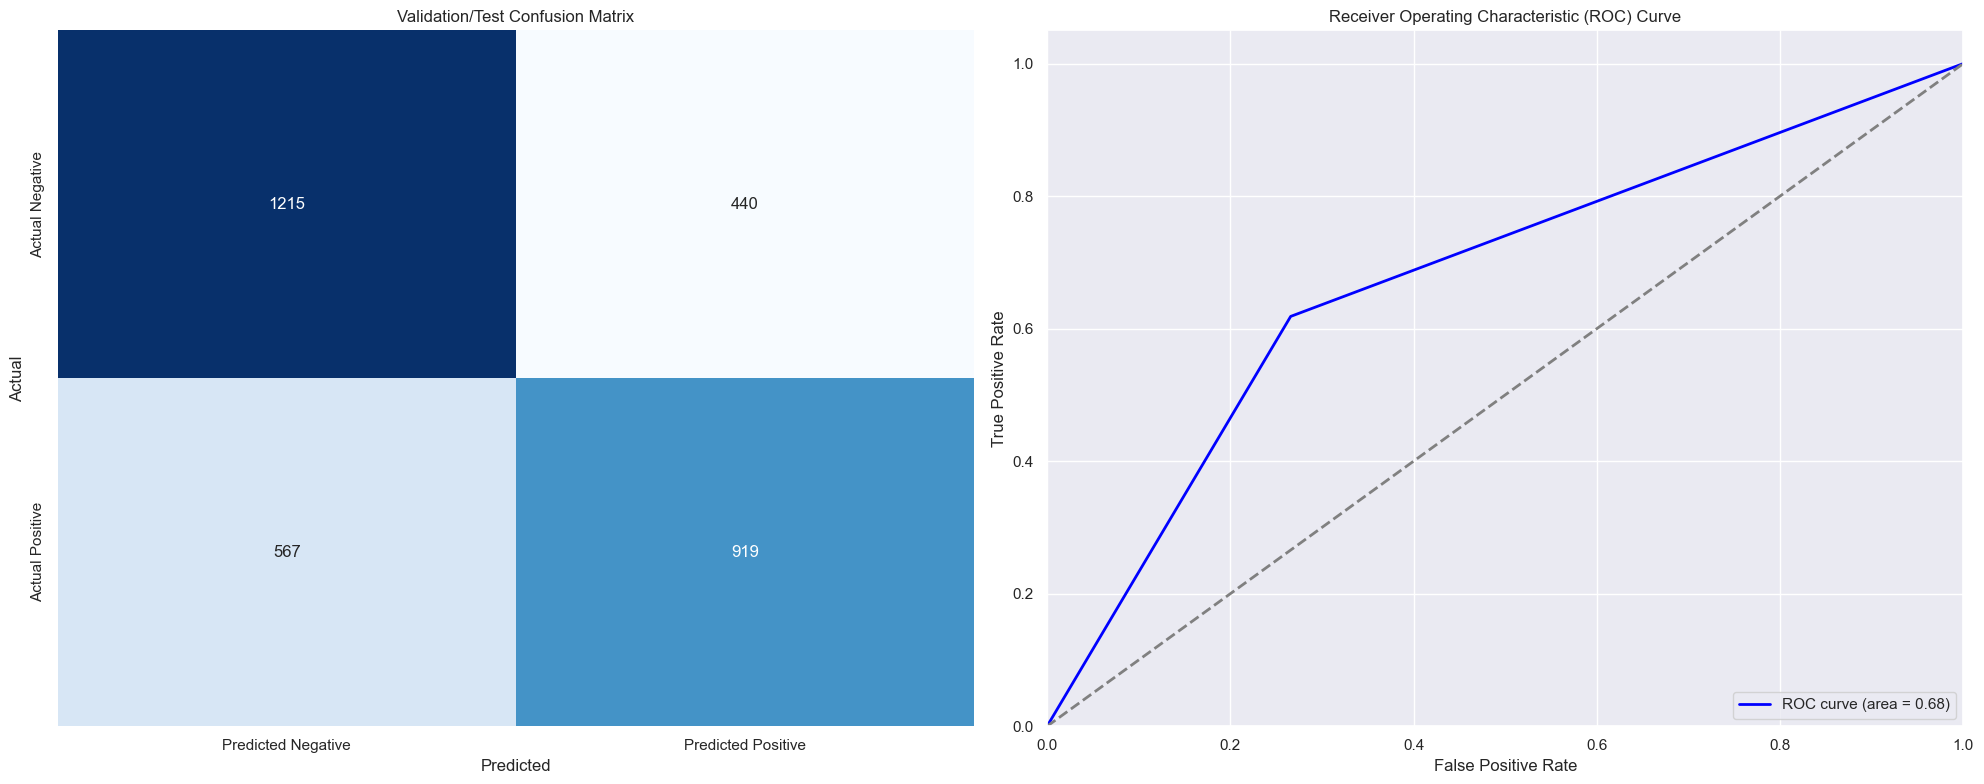

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783827,0.886272,0.795050,0.692677,0.720854,0.691843,0.789057
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.779140,0.730180,0.757729,0.702599,0.787439,0.823085,0.776633
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.679401,0.618439,0.646046,0.598724,0.676233,0.734139,0.676289


In [20]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### AdaBoostClassifier

In [21]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 1.0]
}
# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# CV with grid search for Hyper-Parameter tuning
ada_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = ada_fit.best_estimator_

CV accuracy: 0.769 +/- 0.010


In [22]:
print(model)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=200, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.66      0.75      6619
        True       0.70      0.89      0.79      5941

    accuracy                           0.77     12560
   macro avg       0.79      0.77      0.77     12560
weighted avg       0.79      0.77      0.77     12560



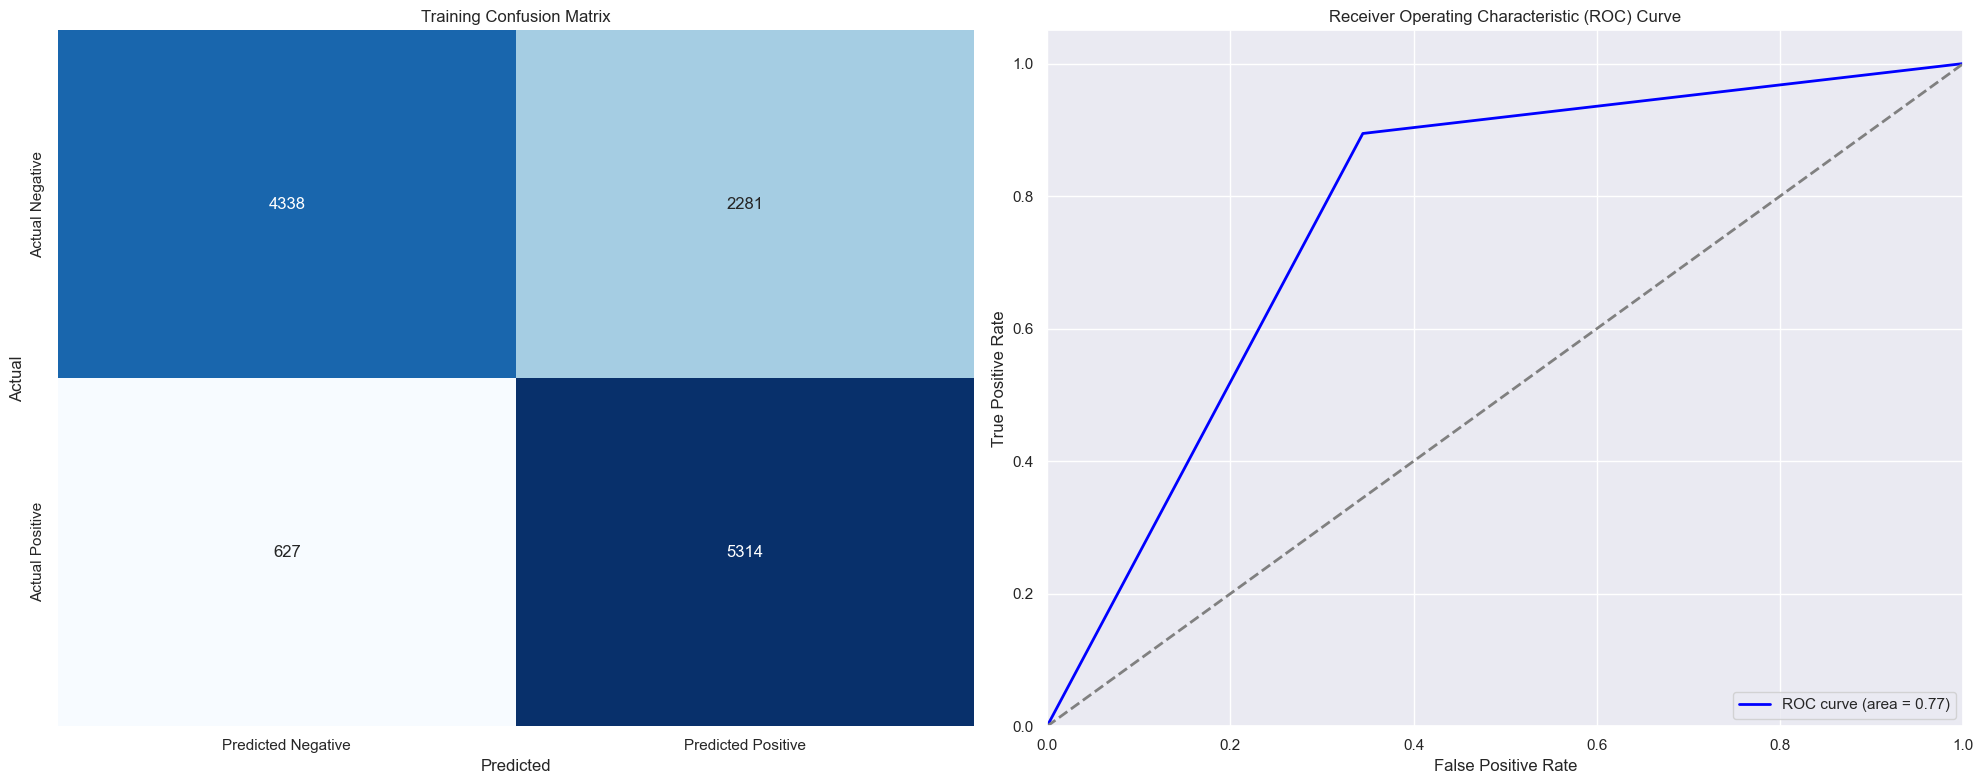

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783827,0.886272,0.795050,0.692677,0.720854,0.691843,0.789057
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.779140,0.730180,0.757729,0.702599,0.787439,0.823085,0.776633
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.679401,0.618439,0.646046,0.598724,0.676233,0.734139,0.676289
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.768471,0.894462,0.785165,0.675750,0.699671,0.655386,0.774924


In [23]:
# initialize variables
Algorithm = 'AdaBoost'
Desc = 'AdaBoost - Grid Search - All Features'
Model = 'ada_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.66      0.75      1655
        True       0.70      0.90      0.79      1486

    accuracy                           0.77      3141
   macro avg       0.79      0.78      0.77      3141
weighted avg       0.79      0.77      0.77      3141



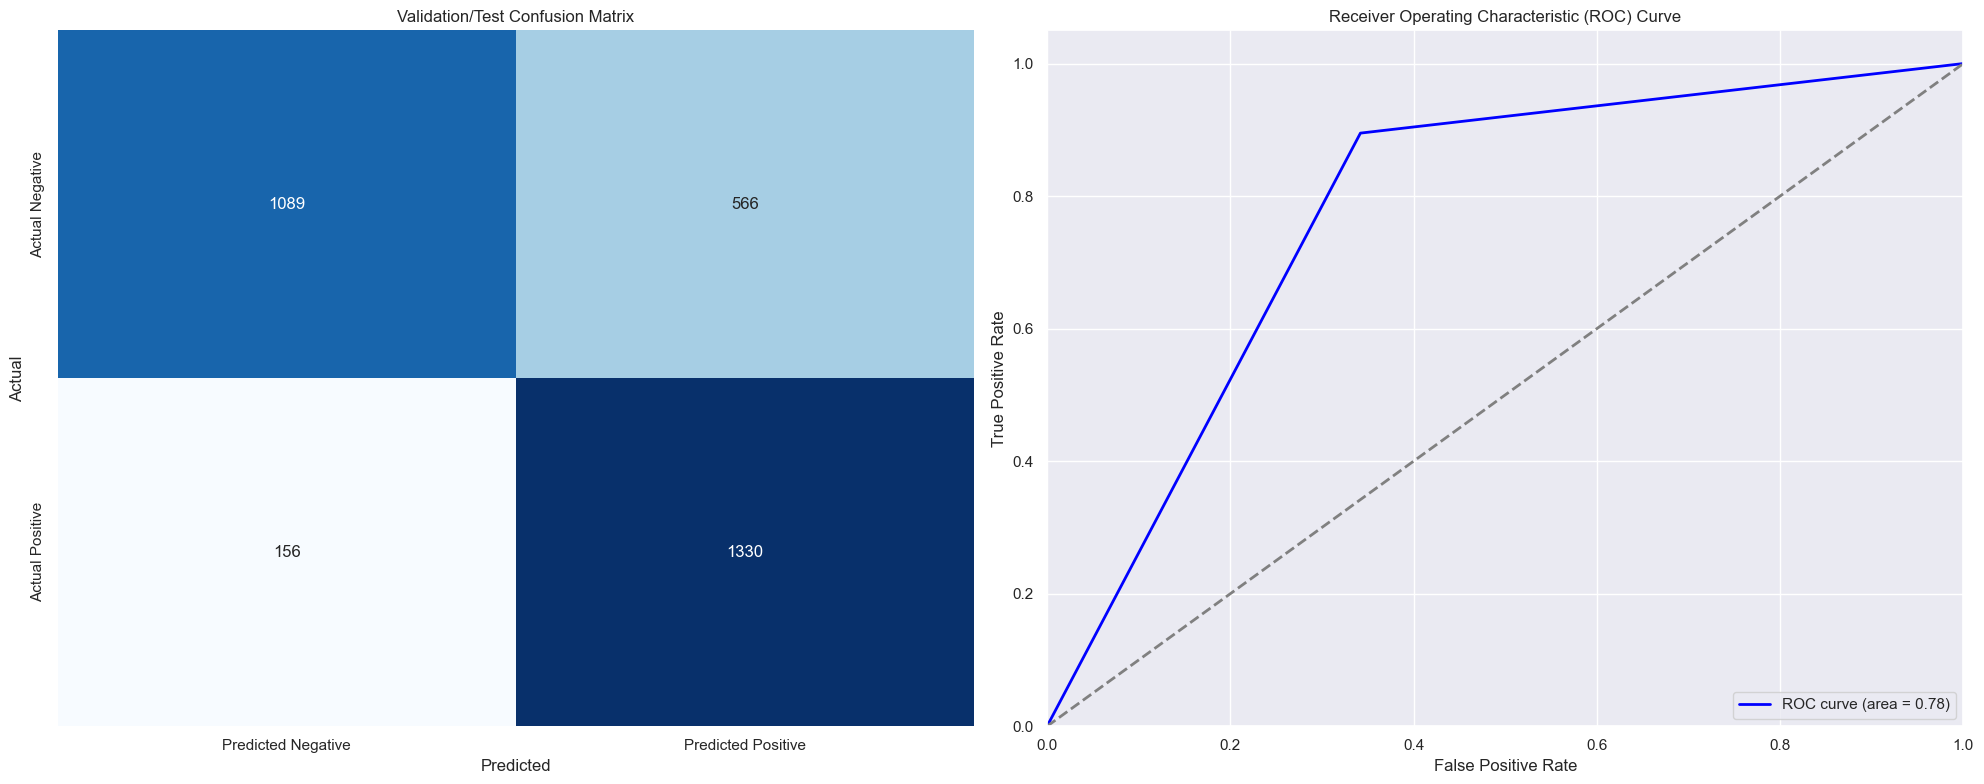

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.774443,0.831678,0.777192,0.686249,0.729407,0.723070,0.777374
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.769182,0.820996,0.770932,0.681241,0.726623,0.722659,0.771827
2,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Training,0.782723,0.867194,0.790608,0.692794,0.726452,0.706904,0.787049
3,LogisticRegression,lrc_fit,LogisticRegression - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.781598,0.870121,0.790342,0.691382,0.723964,0.702115,0.786118
4,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Training,0.796178,0.890254,0.805145,0.706149,0.734890,0.711739,0.800997
5,XGBClassifier,xgb_fit,XGBClassifier - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783827,0.886272,0.795050,0.692677,0.720854,0.691843,0.789057
6,KNN,knn_fit,KNN - Grid Search - All Features,Training,0.779140,0.730180,0.757729,0.702599,0.787439,0.823085,0.776633
7,KNN,knn_fit,KNN - Grid Search - All Features,Validation/test,0.679401,0.618439,0.646046,0.598724,0.676233,0.734139,0.676289
8,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Training,0.768471,0.894462,0.785165,0.675750,0.699671,0.655386,0.774924
9,AdaBoost,ada_fit,AdaBoost - Grid Search - All Features,Validation/test,0.770137,0.895020,0.786517,0.677502,0.701477,0.658006,0.776513


In [24]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

In [25]:
def LogisticFeatureImportance(model, figsize=(8,10), fontsize=8):
    """
    This function analyzes the importance of features in a logistic regression model by processing its 
    coefficients. It creates a DataFrame with each feature's name, coefficient, effect description, 
    odds ratio, percentage change in odds, and probability, including a horizontal bar plot of feature importance.
    
    Args:
    - model: Trained logistic regression model (e.g., from sklearn).
    - figsize: Tuple defining the figure size for the plot (default: (8, 10)).
    - fontsize: Font size for axis labels and title (default: 8).
    
    Returns:
    - DataFrame: A DataFrame with feature importance details.
    """
    # Check if the model has been fitted and has the coef_ attribute
    if not hasattr(model, 'coef_'):
        raise ValueError("The model must be a fitted logistic regression model.")
    
    # Get feature names and coefficients
    feature_names = model.feature_names_in_
    coefficients = model.coef_
    
    # If it's a multi-class logistic regression, handle each class separately
    if coefficients.ndim > 1:
        coeff_list = []
        for i in range(coefficients.shape[0]):
            class_name = f"Class {i}"
            class_coefficients = coefficients[i]
            coeff_list.append(pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': class_coefficients,
                'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in class_coefficients],
                'Odd Ratio': np.exp(class_coefficients),
                'Percentage Change in Odds': (np.exp(class_coefficients) - 1) * 100,
                'Probability': np.exp(class_coefficients) / (1 + np.exp(class_coefficients)),
                'Class': class_name
            }))
        # Concatenate dataframes for all classes
        LRcoeff_df = pd.concat(coeff_list, ignore_index=True)
    else:
        # Single class logistic regression
        LRcoeff_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients[0],
            'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in coefficients[0]],
            'Odd Ratio': np.exp(coefficients[0]),
            'Percentage Change in Odds': (np.exp(coefficients[0]) - 1) * 100,
            'Probability': np.exp(coefficients[0]) / (1 + np.exp(coefficients[0])),
        })
    
    # Sort by Coefficient for better visualization
    LRcoeff_df = LRcoeff_df.sort_values(by='Coefficient', ascending=False)
    
    # Reset the index
    LRcoeff_df.reset_index(drop=True, inplace=True)
    
    # Plot feature importance (using Odds Ratio for better interpretability)
    plt.figure(figsize=figsize)
    if 'Class' in LRcoeff_df.columns:
        # Plot for multi-class case
        for class_name in LRcoeff_df['Class'].unique():
            class_df = LRcoeff_df[LRcoeff_df['Class'] == class_name]
            plt.barh(class_df['Feature'], class_df['Odd Ratio'], label=class_name)
    else:
        # Single class logistic regression
        plt.barh(LRcoeff_df['Feature'], LRcoeff_df['Odd Ratio'], color='steelblue')
    
    plt.axvline(1, color='red', linestyle='--', label="Odd Ratio = 1 (No Effect)")
    plt.xlabel("Odds Ratio")
    plt.ylabel("Features")
    plt.title("Feature Importance in Logistic Regression")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return LRcoeff_df


In [26]:
# best model
model = lrc_fit.best_estimator_

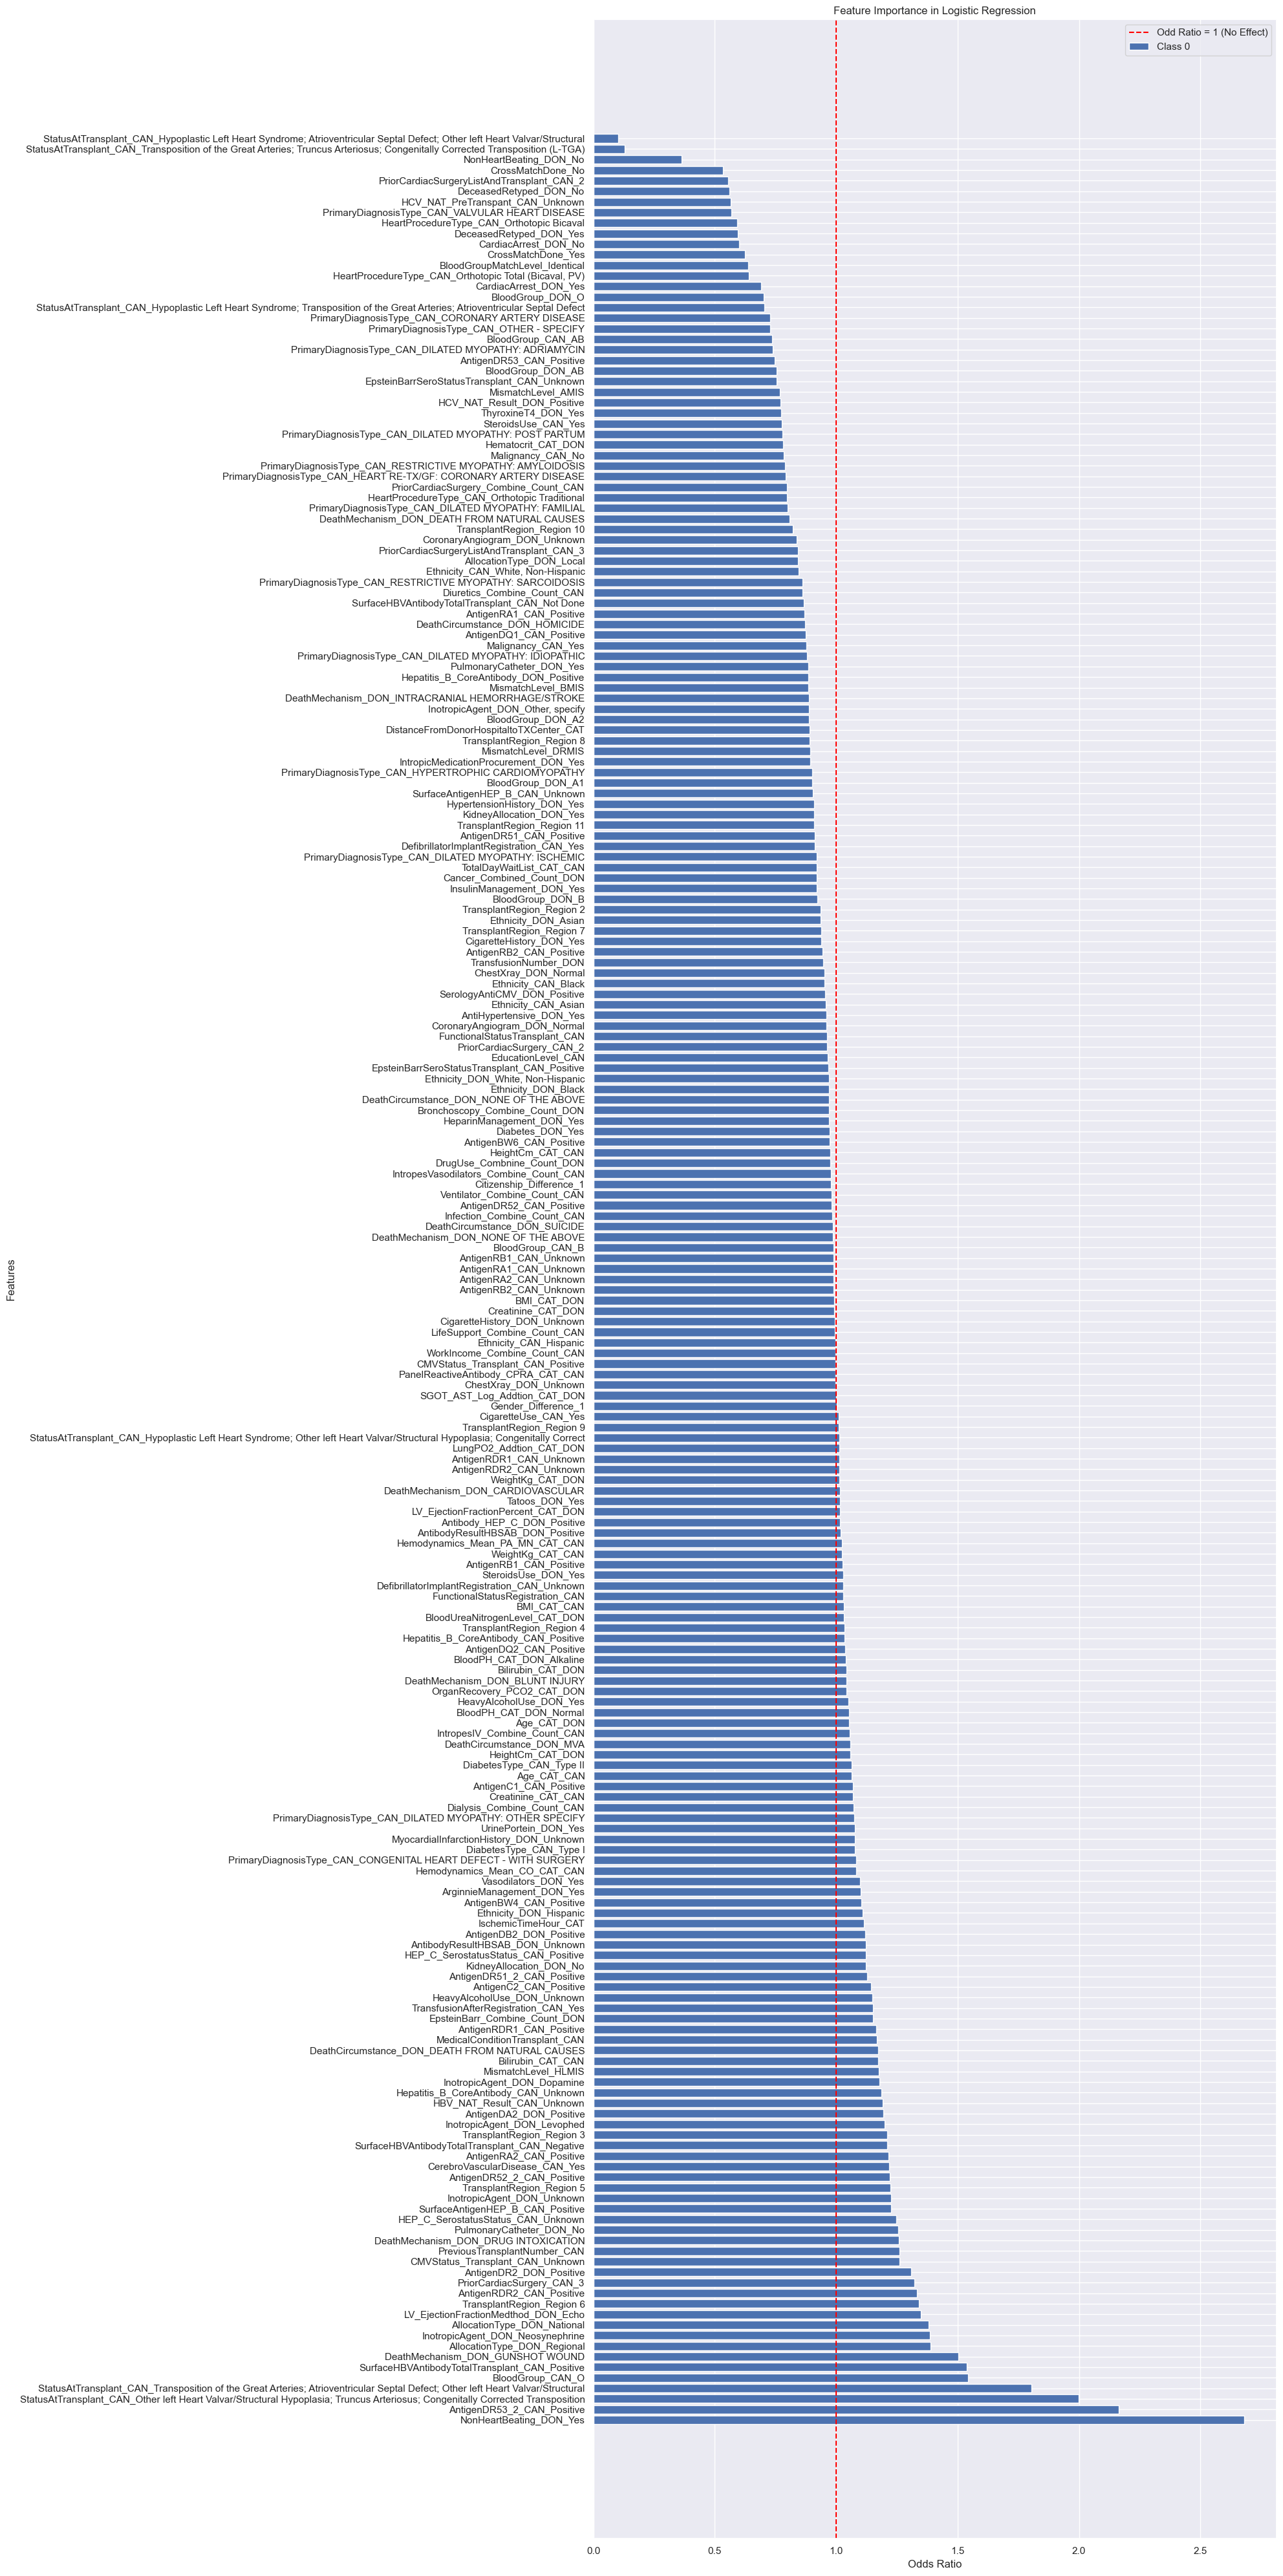

In [27]:
# feature importance & plot
lrc_df = LogisticFeatureImportance(model, figsize=(20,40), fontsize=5)

In [28]:
lrc_df.head()

,Feature,Coefficient,Description,Odd Ratio,Percentage Change in Odds,Probability,Class
0,NonHeartBeating_DON_Yes,0.985706,Increase in the log-odds of the Positive Class,2.679704,167.970424,0.728239,Class 0
1,AntigenDR53_2_CAN_Positive,0.772116,Increase in the log-odds of the Positive Class,2.164342,116.434218,0.683979,Class 0
2,StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.692904,Increase in the log-odds of the Positive Class,1.999514,99.951426,0.666613,Class 0
3,StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.589761,Increase in the log-odds of the Positive Class,1.803557,80.355717,0.643310,Class 0
4,BloodGroup_CAN_O,0.434052,Increase in the log-odds of the Positive Class,1.543498,54.349850,0.606841,Class 0
